# Import Dependency

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from copy import deepcopy
from dataclasses import dataclass, field

In [67]:
# import sys
# !{sys.executable} -m pip install seaborn

In [ ]:
# pd.set_option('display.max_rows', 100)
# pd.set_option('display.max_columns', None)

# Read Dataset

In [3]:
base_dir = 'dataset'
data = []
labels = []
groups = []
categories = ['disgust', 'fear', 'happiness', 'others', 'repression', 'sadness', 'surprise']

df_meta = pd.read_excel('CASME2-INFO.xlsx')

for index, row in df_meta.iterrows():
    subject = str(row['Subject']).zfill(2)
    filename = str(row['Filename']).strip()
    apex = row['ApexFrame']
    emotion = str(row['Estimated Emotion']).strip().lower()
    
    if emotion not in categories or pd.isna(apex) or str(apex).strip() == '/':
        continue
        
    apex_frame = int(apex)
    seq_path = os.path.join(base_dir, f"sub{subject}", filename)
    
    if os.path.exists(seq_path):
        img_path = None
        for file_name in os.listdir(seq_path):
            if file_name == f"img{apex_frame}.jpg" or file_name == f"img{apex_frame:03d}.jpg":
                img_path = os.path.join(seq_path, file_name)
                break
                
        if img_path is not None:
            img = cv2.imread(img_path)
            if img is not None:
                data.append(img)
                labels.append(emotion)
                groups.append(subject)

# EDA

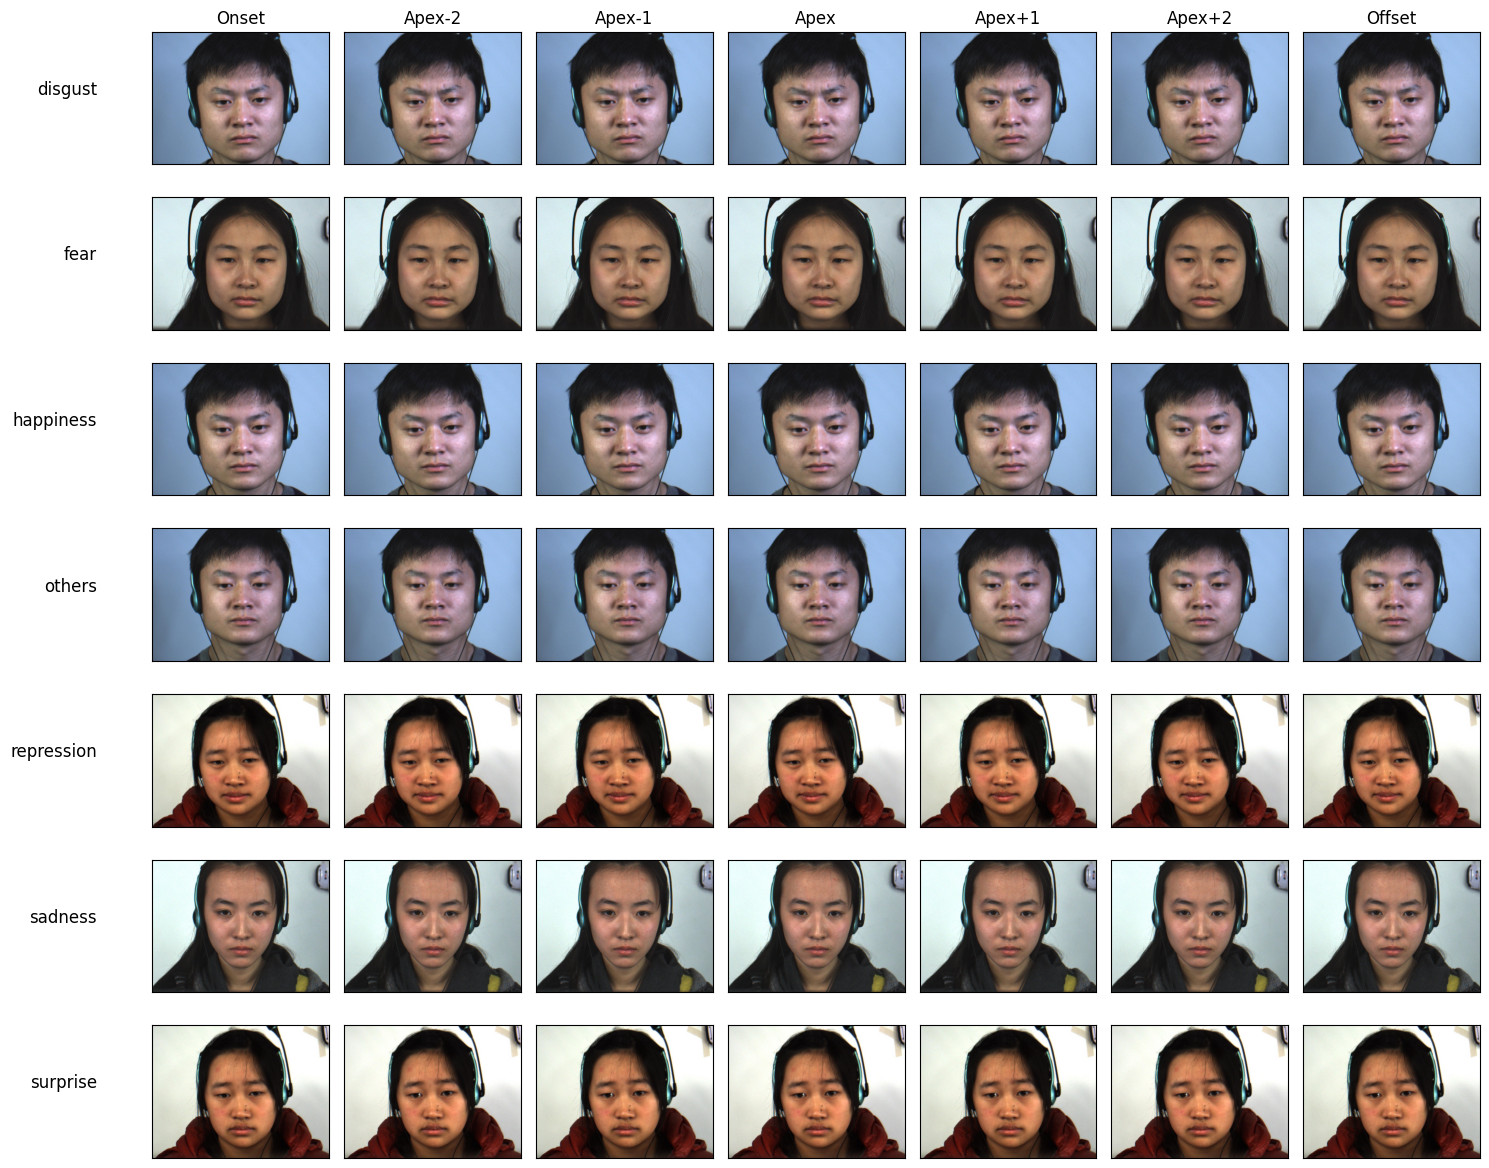

In [4]:
df_meta.columns = df_meta.columns.str.strip()
df_meta['Estimated Emotion'] = df_meta['Estimated Emotion'].astype(str).str.strip().str.lower()

plt.figure(figsize=(15, 12))
titles = ["Onset", "Apex-2", "Apex-1", "Apex", "Apex+1", "Apex+2", "Offset"]

for row_idx, category in enumerate(categories):
    match = df_meta[df_meta['Estimated Emotion'] == category]
    
    valid_rows = match[
        ~match['OnsetFrame'].astype(str).str.contains('/') & 
        ~match['ApexFrame'].astype(str).str.contains('/') & 
        ~match['OffsetFrame'].astype(str).str.contains('/')
    ]
    
    if not valid_rows.empty:
        first_match = valid_rows.iloc[0]
        subject = str(first_match['Subject']).zfill(2)
        filename = str(first_match['Filename']).strip()
        
        apex_frame = int(first_match['ApexFrame'])
        onset_frame = int(first_match['OnsetFrame'])
        offset_frame = int(first_match['OffsetFrame'])
        
        seq_path = os.path.join(base_dir, f"sub{subject}", filename)
        
        target_frames = [
            onset_frame, 
            max(onset_frame, apex_frame - 2), 
            max(onset_frame, apex_frame - 1), 
            apex_frame, 
            min(offset_frame, apex_frame + 1), 
            min(offset_frame, apex_frame + 2), 
            offset_frame
        ]
        
        for col_idx, target_frame in enumerate(target_frames):
            img_path = os.path.join(seq_path, f"img{target_frame}.jpg")
            if not os.path.exists(img_path):
                img_path = os.path.join(seq_path, f"img{target_frame:03d}.jpg")
                
            plt.subplot(len(categories), len(titles), row_idx * len(titles) + col_idx + 1)
            
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None:
                    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            
            if col_idx == 0:
                plt.ylabel(category, fontsize=12, rotation=0, labelpad=40, ha='right')
            
            if row_idx == 0:
                plt.title(titles[col_idx])
                    
            plt.xticks([])
            plt.yticks([])

plt.tight_layout()
plt.show()

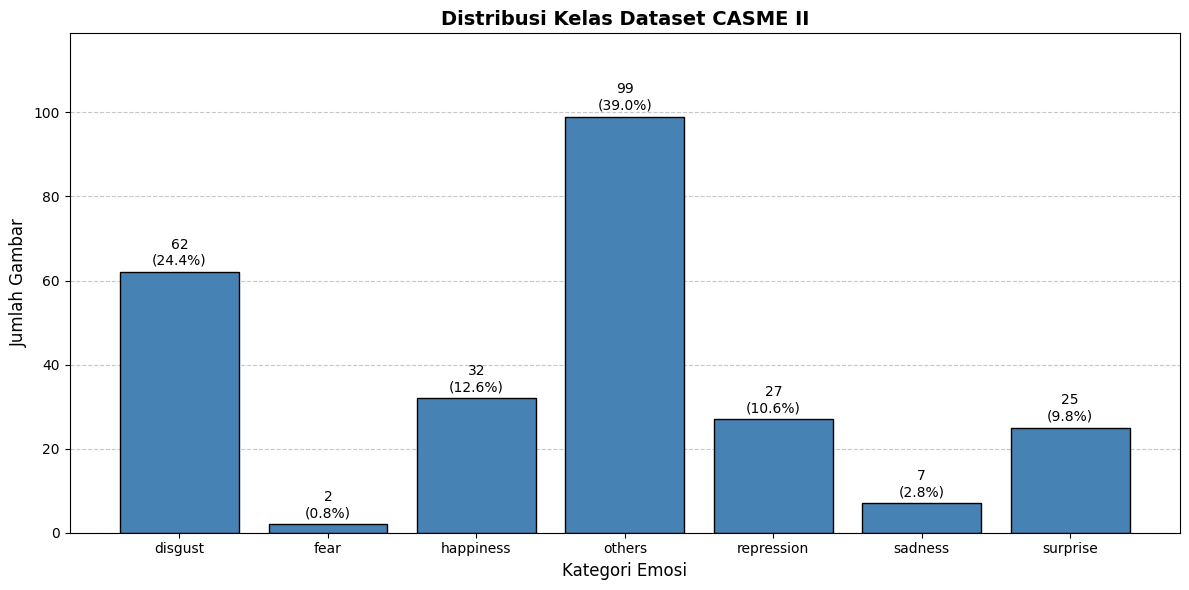

In [ ]:
counts = Counter(labels)
frequencies = [counts[category] for category in categories]
total_data = sum(frequencies)

plt.figure(figsize=(12, 6))
bars = plt.bar(categories, frequencies, color='steelblue', edgecolor='black', zorder=2)

for bar in bars:
    yval = bar.get_height()
    percentage = f"{(yval / total_data) * 100:.1f}%" if total_data > 0 else "0%"
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval}\n({percentage})", ha='center', va='bottom', fontsize=10)

plt.title('Distribusi Kelas Dataset CASME II', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Emosi', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)
plt.ylim(0, max(frequencies) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()

In [10]:
dist_data = []

for category in categories:
    pct = (counts[category] / len(labels)) * 100 if len(labels) > 0 else 0
    dist_data.append({
        "Kategori": category,
        "Jumlah Gambar": counts[category],
        "Persentase": f"{pct:.1f}%"
    })

dist_data.append({
    "Kategori": "Total",
    "Jumlah Gambar": len(labels),
    "Persentase": "100.0%"
})

df_dist = pd.DataFrame(dist_data)
display(df_dist)

,Kategori,Jumlah Gambar,Persentase
0,disgust,62,24.4%
1,fear,2,0.8%
2,happiness,32,12.6%
3,others,99,39.0%
4,repression,27,10.6%
5,sadness,7,2.8%
6,surprise,25,9.8%
7,Total,254,100.0%


## Distribusi Durasi Dataset

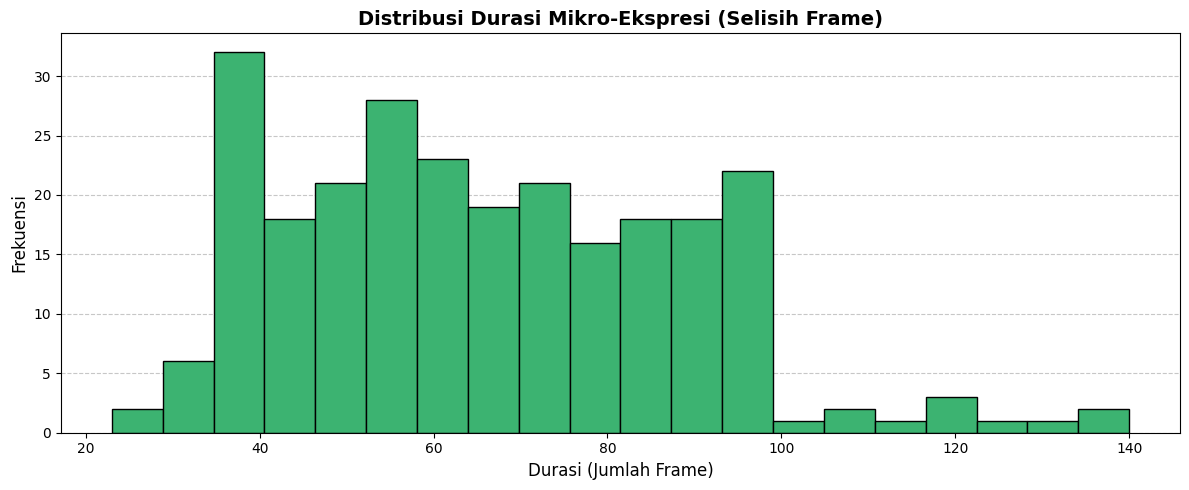

In [11]:
valid_duration = df_meta[
    ~df_meta['OnsetFrame'].astype(str).str.contains('/') & 
    ~df_meta['OffsetFrame'].astype(str).str.contains('/')
].copy()

valid_duration['Duration'] = valid_duration['OffsetFrame'].astype(int) - valid_duration['OnsetFrame'].astype(int)

plt.figure(figsize=(12, 5))
plt.hist(valid_duration['Duration'], bins=20, color='mediumseagreen', edgecolor='black', zorder=2)
plt.title('Distribusi Durasi Mikro-Ekspresi (Selisih Frame)', fontsize=14, fontweight='bold')
plt.xlabel('Durasi (Jumlah Frame)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()

In [12]:
dur_bins = pd.cut(valid_duration['Duration'], bins=10)
dur_counts = dur_bins.value_counts().sort_index()

dur_table_data = []
for interval, count in dur_counts.items():
    pct = (count / len(valid_duration)) * 100 if len(valid_duration) > 0 else 0
    dur_table_data.append({
        "Rentang Durasi (Frame)": f"{int(round(interval.left))} - {int(round(interval.right))}",
        "Jumlah Sampel": count,
        "Persentase": f"{pct:.1f}%"
    })

df_dur_dist = pd.DataFrame(dur_table_data)
display(df_dur_dist)

,Rentang Durasi (Frame),Jumlah Sampel,Persentase
0,23 - 35,8,3.1%
1,35 - 46,50,19.6%
2,46 - 58,49,19.2%
3,58 - 70,42,16.5%
4,70 - 82,37,14.5%
5,82 - 93,36,14.1%
6,93 - 105,23,9.0%
7,105 - 117,3,1.2%
8,117 - 128,4,1.6%
9,128 - 140,3,1.2%


## Class Tiap Subjek

In [5]:
df_subject_class = pd.crosstab(
    pd.Series(groups, name='Subjek'), 
    pd.Series(labels, name='Kategori Emosi'),
    margins=True,
    margins_name='Total'
)

display(df_subject_class)

Kategori Emosi,disgust,fear,happiness,others,repression,sadness,surprise,Total
Subjek,,,,,,,,
01,2,0,1,6,0,0,0,9
02,0,0,1,4,5,0,3,13
03,4,0,0,2,0,0,1,7
04,2,0,0,2,0,0,0,4
05,1,0,1,12,0,0,5,19
06,1,0,1,1,0,0,2,5
07,5,0,0,4,0,0,0,9
08,0,0,0,2,1,0,0,3
09,0,1,5,3,5,0,0,14


## Corrupt File

In [14]:
corrupted_files = []

for root, _, files in os.walk(base_dir):
    for file_name in files:
        if file_name.endswith('.jpg'):
            img_path = os.path.join(root, file_name)
            try:
                with open(img_path, 'rb') as f:
                    f.seek(-2, 2)
                    if f.read() != b'\xff\xd9':
                        corrupted_files.append(img_path)
            except Exception:
                corrupted_files.append(img_path)

print("Jumlah file rusak ditemukan:", len(corrupted_files))
if len(corrupted_files) > 0:
    for f_path in corrupted_files:
        print(f_path)

Jumlah file rusak ditemukan: 0


# GPU SETUP

In [17]:
import torch

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    device = torch.device("cuda")
    x = torch.ones(3, 3).to(device)
    print("Running on GPU")
else:
    device = torch.device("cpu")
    print("Running on CPU")

CUDA Available: True
Running on GPU


# Preparation

## Definisi Struktur Dasar (Kromosom, Dataset, Arsitektur Hybrid)

In [18]:
@dataclass
class GAChromosome:
    mask_logits: np.ndarray = field(default_factory=lambda: np.random.randn(128) * 0.1)
    num_heads: int = 8
    mixer_depth: int = 4
    dropout: float = 0.2
    lr: float = 1e-3

    @staticmethod
    def random():
        return GAChromosome(
            mask_logits=np.random.randn(128) * 0.1,
            num_heads=int(np.random.choice([4, 8])),
            mixer_depth=int(np.random.choice([2, 3, 4, 6])),
            dropout=float(np.random.uniform(0.1, 0.35)),
            lr=float(np.random.choice([1e-4, 5e-4, 1e-3])),
        )

    def crossover(self, other: "GAChromosome"):
        cp = np.random.randint(1, 128)
        def pick(a, b): return a if np.random.rand() < 0.5 else b
        c1 = GAChromosome(
            mask_logits=np.concatenate([self.mask_logits[:cp], other.mask_logits[cp:]]),
            num_heads=pick(self.num_heads, other.num_heads),
            mixer_depth=pick(self.mixer_depth, other.mixer_depth),
            dropout=(self.dropout + other.dropout) / 2,
            lr=pick(self.lr, other.lr),
        )
        c2 = GAChromosome(
            mask_logits=np.concatenate([other.mask_logits[:cp], self.mask_logits[cp:]]),
            num_heads=pick(other.num_heads, self.num_heads),
            mixer_depth=pick(other.mixer_depth, self.mixer_depth),
            dropout=(self.dropout + other.dropout) / 2,
            lr=pick(other.lr, self.lr),
        )
        return c1, c2

    def mutate(self, rate: float = 0.1):
        self.mask_logits += np.random.randn(128) * rate
        if np.random.rand() < rate:
            self.num_heads = int(np.random.choice([4, 8]))
        if np.random.rand() < rate:
            self.mixer_depth = int(np.random.choice([2, 3, 4, 6]))
        if np.random.rand() < 0.3:
            self.dropout = float(np.clip(self.dropout + np.random.randn() * 0.05, 0.05, 0.5))
        if np.random.rand() < rate:
            self.lr = float(np.random.choice([1e-4, 5e-4, 1e-3]))

class MicroExpressionDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        self.label_mapping = {cat: i for i, cat in enumerate(['disgust', 'fear', 'happiness', 'others', 'repression', 'sadness', 'surprise'])}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.label_mapping[self.labels[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

class CABMFMER_TightGA(nn.Module):
    def __init__(self, num_classes=7, dim=128, mixer_depth=4, num_heads=8, mlp_dim=512, dropout=0.2):
        super().__init__()
        self.mixer_depth = mixer_depth
        self.patch_size = 16
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, dim, kernel_size=7, stride=2, padding=3),
            nn.GELU(), nn.BatchNorm2d(dim), nn.MaxPool2d(2, 2)
        )
        self.ga_mask = nn.Parameter(torch.zeros(dim))
        self.depthwise_convs = nn.ModuleList([nn.Conv2d(dim, dim, kernel_size=3, groups=dim, padding=1) for _ in range(mixer_depth)])
        self.batch_norms_dw = nn.ModuleList([nn.BatchNorm2d(dim) for _ in range(mixer_depth)])
        self.pointwise_convs = nn.ModuleList([nn.Conv2d(dim, dim, kernel_size=1) for _ in range(mixer_depth)])
        self.batch_norms_pw = nn.ModuleList([nn.BatchNorm2d(dim) for _ in range(mixer_depth)])
        self.gelu = nn.GELU()
        self.feature_align = nn.AdaptiveAvgPool2d((48, 48))
        self.patch_embed = nn.Conv2d(dim, dim, kernel_size=self.patch_size, stride=self.patch_size)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=num_heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.mlp_head = nn.Linear(dim, num_classes)

    def init_from_chromosome(self, chrom: GAChromosome):
        with torch.no_grad():
            self.ga_mask.data = torch.tensor(chrom.mask_logits, dtype=torch.float32).to(self.ga_mask.device)

    def extract_to_chromosome(self, chrom: GAChromosome):
        chrom.mask_logits = self.ga_mask.detach().cpu().numpy().copy()

    def forward(self, x):
        x = self.init_conv(x)
        soft_mask = torch.sigmoid(self.ga_mask)
        x = x * soft_mask.view(1, -1, 1, 1)
        for i in range(self.mixer_depth):
            residual = x
            x = self.depthwise_convs[i](x)
            x = self.gelu(x)
            x = self.batch_norms_dw[i](x)
            x = x + residual
            x = self.pointwise_convs[i](x)
            x = self.gelu(x)
            x = self.batch_norms_pw[i](x)
        x = self.feature_align(x)
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.transformer_encoder(x)
        x = x.transpose(1, 2)
        x = self.gap(x).squeeze(-1)
        return self.mlp_head(x)

## Prapemrosesan Data Loader

In [19]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Evaluasi dengan Leave One Subject out

In [22]:
X_arr = np.array(data)
y_arr = np.array(labels)
g_arr = np.array(groups)

logo = LeaveOneGroupOut()
fold_metrics = []

## Parameter

In [23]:
pop_size = 4
generations = 5
warmup_epochs = 3
mutation_rate = 0.1
crossover_rate = 0.8
dim = 128
criterion = nn.CrossEntropyLoss()

## Evolusi GA (Menggunakan Validation Set)

In [ ]:
print(f"Memulai Validasi Silang LOSO ({len(np.unique(g_arr))} Subjek)")


for fold, (train_val_idx, test_idx) in enumerate(logo.split(X_arr, y_arr, g_arr), 1):
    test_subj = g_arr[test_idx[0]]
    
    X_tv = X_arr[train_val_idx]
    y_tv = y_arr[train_val_idx]
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=0.2, random_state=42
    )
    
    X_test = X_arr[test_idx]
    y_test = y_arr[test_idx]

    train_dataset = MicroExpressionDataset(X_train, y_train, transform=train_transform)
    val_dataset = MicroExpressionDataset(X_val, y_val, transform=eval_transform)
    test_dataset = MicroExpressionDataset(X_test, y_test, transform=eval_transform)
    
    label_mapping = {cat: i for i, cat in enumerate(['disgust', 'fear', 'happiness', 'others', 'repression', 'sadness', 'surprise'])}
    train_labels_int = [label_mapping[m] for m in y_train]
    class_counts = np.bincount(train_labels_int, minlength=7)
    sample_weights = [1.0 / (class_counts[m] + 1e-8) for m in train_labels_int]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    
    train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    population = [GAChromosome.random() for _ in range(pop_size)]
    best_chrom = None
    best_fitness = -1.0

    for gen in range(generations):
        fitness_scores = []
        for idx, chrom in enumerate(population):
            try:
                model = CABMFMER_TightGA(
                    num_classes=7, dim=dim, mixer_depth=chrom.mixer_depth,
                    num_heads=chrom.num_heads, dropout=chrom.dropout
                ).to(device)
                model.init_from_chromosome(chrom)
                optimizer = optim.Adam(model.parameters(), lr=chrom.lr, weight_decay=1e-5)
                
                for _ in range(warmup_epochs):
                    model.train()
                    for imgs, lbls in train_loader:
                        imgs, lbls = imgs.to(device), lbls.to(device)
                        optimizer.zero_grad()
                        loss = criterion(model(imgs), lbls)
                        loss.backward()
                        optimizer.step()
                        
                model.train()
                imgs, lbls = next(iter(train_loader))
                imgs, lbls = imgs.to(device), lbls.to(device)
                optimizer.zero_grad()
                criterion(model(imgs), lbls).backward()
                grad_norm = model.ga_mask.grad.norm().item() if model.ga_mask.grad is not None else 0.0
                
                with torch.no_grad():
                    soft_mask = torch.sigmoid(model.ga_mask)
                    active_ratio = (soft_mask > 0.5).float().mean().item()
                    
                model.eval()
                correct_val = total_val = 0
                with torch.no_grad():
                    for imgs, lbls in val_loader:
                        imgs, lbls = imgs.to(device), lbls.to(device)
                        _, pred = torch.max(model(imgs), 1)
                        total_val += lbls.size(0)
                        correct_val += (pred == lbls).sum().item()
                        
                acc = correct_val / total_val if total_val > 0 else 0
                fitness = 0.6 * acc + 0.2 * min(grad_norm / 10.0, 1.0) + 0.2 * (1.0 - active_ratio)
                
                model.extract_to_chromosome(chrom)
                fitness_scores.append(fitness)
                
                if fitness > best_fitness:
                    best_fitness = fitness
                    best_chrom = deepcopy(chrom)
                    
            except Exception:
                fitness_scores.append(0.0)

        scores = np.array(fitness_scores)
        if scores.sum() == 0:
            probs = np.ones(pop_size) / pop_size
        else:
            probs = scores / scores.sum()
            probs = probs / probs.sum()
            
        idxs = np.random.choice(pop_size, size=pop_size, p=probs)
        parents = [population[i] for i in idxs]
        
        next_pop = []
        for i in range(0, pop_size, 2):
            p1 = parents[i]
            p2 = parents[i + 1 if i + 1 < pop_size else 0]
            if np.random.rand() < crossover_rate:
                c1, c2 = p1.crossover(p2)
            else:
                c1, c2 = deepcopy(p1), deepcopy(p2)
            c1.mutate(mutation_rate)
            c2.mutate(mutation_rate)
            next_pop.extend([c1, c2])
        population = next_pop[:pop_size]

    model = CABMFMER_TightGA(
        num_classes=7, dim=dim, mixer_depth=best_chrom.mixer_depth,
        num_heads=best_chrom.num_heads, dropout=best_chrom.dropout
    ).to(device)
    model.init_from_chromosome(best_chrom)
    optimizer = optim.Adam(model.parameters(), lr=best_chrom.lr, weight_decay=1e-5)
    
    best_test_acc = 0.0
    patience = 5
    patience_ctr = 0
    
    for epoch in range(20):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
            
        model.eval()
        correct_test = total_test = 0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                _, pred = torch.max(out, 1)
                total_test += lbls.size(0)
                correct_test += (pred == lbls).sum().item()
                
        test_acc = correct_test / total_test if total_test > 0 else 0
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), f"models/best_model_fold_{fold}.pth")
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break
                
    fold_metrics.append({
        "Fold": fold,
        "Subjek Diuji": test_subj,
        "Akurasi Test": f"{best_test_acc*100:.2f}%",
        "GA Lr": f"{best_chrom.lr:.0e}",
        "GA Depth": best_chrom.mixer_depth
    })
    
    print(f"Fold {fold:02d} Selesai | Subjek: {test_subj} | Akurasi: {best_test_acc*100:.2f}%")

print(f"{'='*50}")
print("Pengujian LOSO Selesai")
df_loso = pd.DataFrame(fold_metrics)
display(df_loso)

Memulai Validasi Silang LOSO (26 Subjek)
Fold 01 Selesai | Subjek: 01 | Akurasi: 66.67%
Fold 02 Selesai | Subjek: 02 | Akurasi: 38.46%
Fold 03 Selesai | Subjek: 03 | Akurasi: 57.14%
Fold 04 Selesai | Subjek: 04 | Akurasi: 50.00%
Fold 05 Selesai | Subjek: 05 | Akurasi: 63.16%
Fold 06 Selesai | Subjek: 06 | Akurasi: 40.00%
Fold 07 Selesai | Subjek: 07 | Akurasi: 55.56%
Fold 08 Selesai | Subjek: 08 | Akurasi: 66.67%
Fold 09 Selesai | Subjek: 09 | Akurasi: 35.71%
Fold 10 Selesai | Subjek: 10 | Akurasi: 0.00%
Fold 11 Selesai | Subjek: 11 | Akurasi: 60.00%
Fold 12 Selesai | Subjek: 12 | Akurasi: 41.67%
Fold 13 Selesai | Subjek: 13 | Akurasi: 75.00%
Fold 14 Selesai | Subjek: 14 | Akurasi: 25.00%
Fold 15 Selesai | Subjek: 15 | Akurasi: 0.00%
Fold 16 Selesai | Subjek: 16 | Akurasi: 25.00%
Fold 17 Selesai | Subjek: 17 | Akurasi: 8.33%
Fold 18 Selesai | Subjek: 18 | Akurasi: 100.00%
Fold 19 Selesai | Subjek: 19 | Akurasi: 25.00%
Fold 20 Selesai | Subjek: 20 | Akurasi: 45.45%
Fold 21 Selesai | Sub

,Fold,Subjek Diuji,Akurasi Test,GA Lr,GA Depth
0,1,01,66.67%,1e-04,6
1,2,02,38.46%,1e-04,2
2,1,01,66.67%,5e-04,4
3,2,02,46.15%,1e-04,3
4,3,03,0.00%,1e-03,4
5,4,04,50.00%,1e-03,6
6,5,05,63.16%,5e-04,4
7,6,06,0.00%,5e-04,2
8,7,07,55.56%,5e-04,3
9,8,08,66.67%,5e-04,6


In [ ]:
df_clean = df_loso.drop_duplicates(subset=['Subjek Diuji'], keep='last').copy()

df_clean['Akurasi Numeric'] = df_clean['Akurasi Test'].str.rstrip('%').astype(float)

mean_acc = df_clean['Akurasi Numeric'].mean()
std_acc = df_clean['Akurasi Numeric'].std()

table_summary = [
    {"Metrik": "Total Subjek", "Nilai": len(df_clean)},
    {"Metrik": "Rata-rata Akurasi (Mean)", "Nilai": f"{mean_acc:.2f}%"},
    {"Metrik": "Standar Deviasi", "Nilai": f"{std_acc:.2f}%"},
    {"Metrik": "Akurasi Tertinggi", "Nilai": f"{df_clean['Akurasi Numeric'].max():.2f}%"},
    {"Metrik": "Akurasi Terendah", "Nilai": f"{df_clean['Akurasi Numeric'].min():.2f}%"}
]

df_summary = pd.DataFrame(table_summary)
display(df_summary) 

,Metrik,Nilai
0,Total Subjek,26
1,Rata-rata Akurasi (Mean),41.68%
2,Standar Deviasi,24.27%
3,Akurasi Tertinggi,100.00%
4,Akurasi Terendah,0.00%


# Inference (Menggunakan Test Set)

In [ ]:
import torch.nn.functional as F

model = CABMFMER_TightGA(
    num_classes=7, 
    dim=128, 
    mixer_depth=6, 
    num_heads=8, 
    dropout=0.2
).to(device)

model.load_state_dict(torch.load("models/best_model_fold_18.pth", map_location=device))
model.eval()

table_data = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device)
        
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        probs_np = probs.cpu().numpy()
        lbls_np = lbls.cpu().numpy()
        pred_np = predicted.cpu().numpy()
        
        for idx in range(len(probs_np)):
            p = probs_np[idx]
            
            vp = p[2] + p[6]
            vn = p[3]
            vd = p[0] + p[1] + p[4] + p[5]
            
            vp_rendah = max(0.0, (0.5 - vp) / 0.5) if vp <= 0.5 else 0.0
            vp_sedang = max(0.0, min(vp / 0.5, (1.0 - vp) / 0.5))
            vp_tinggi = max(0.0, (vp - 0.5) / 0.5) if vp >= 0.5 else 0.0
            
            vn_rendah = max(0.0, (0.5 - vn) / 0.5) if vn <= 0.5 else 0.0
            vn_sedang = max(0.0, min(vn / 0.5, (1.0 - vn) / 0.5))
            vn_tinggi = max(0.0, (vn - 0.5) / 0.5) if vn >= 0.5 else 0.0
            
            vd_rendah = max(0.0, (0.5 - vd) / 0.5) if vd <= 0.5 else 0.0
            vd_sedang = max(0.0, min(vd / 0.5, (1.0 - vd) / 0.5))
            vd_tinggi = max(0.0, (vd - 0.5) / 0.5) if vd >= 0.5 else 0.0
            
            w1 = min(vp_tinggi, vd_rendah)
            w2 = min(vn_tinggi, vp_rendah, vd_rendah)
            w3 = vd_tinggi
            w4 = min(vp_sedang, vn_sedang)
            w5 = min(vp_sedang, vd_sedang)
            w6 = min(vn_sedang, vd_sedang)
            
            total_w = w1 + w2 + w3 + w4 + w5 + w6
            score = ((w1 * 90.0) + (w2 * 60.0) + (w3 * 25.0) + (w4 * 70.0) + (w5 * 50.0) + (w6 * 40.0)) / total_w if total_w > 0 else 50.0
            
            table_data.append({
                "Label Asli": categories[lbls_np[idx]],
                "Prediksi": categories[pred_np[idx]],
                "Positif (Vp)": f"{vp*100:.1f}%",
                "Netral (Vn)": f"{vn*100:.1f}%",
                "Negatif (Vd)": f"{vd*100:.1f}%",
                "Engagement Score": round(score, 2)
            })

df_results = pd.DataFrame(table_data)
df_results.index += 1
display(df_results.head(20))

df_results.to_csv("detailed_predictions.csv", index_label="No")

RuntimeError: Error(s) in loading state_dict for CABMFMER_TightGA:
	Missing key(s) in state_dict: "depthwise_convs.3.weight", "depthwise_convs.3.bias", "depthwise_convs.4.weight", "depthwise_convs.4.bias", "depthwise_convs.5.weight", "depthwise_convs.5.bias", "batch_norms_dw.3.weight", "batch_norms_dw.3.bias", "batch_norms_dw.3.running_mean", "batch_norms_dw.3.running_var", "batch_norms_dw.4.weight", "batch_norms_dw.4.bias", "batch_norms_dw.4.running_mean", "batch_norms_dw.4.running_var", "batch_norms_dw.5.weight", "batch_norms_dw.5.bias", "batch_norms_dw.5.running_mean", "batch_norms_dw.5.running_var", "pointwise_convs.3.weight", "pointwise_convs.3.bias", "pointwise_convs.4.weight", "pointwise_convs.4.bias", "pointwise_convs.5.weight", "pointwise_convs.5.bias", "batch_norms_pw.3.weight", "batch_norms_pw.3.bias", "batch_norms_pw.3.running_mean", "batch_norms_pw.3.running_var", "batch_norms_pw.4.weight", "batch_norms_pw.4.bias", "batch_norms_pw.4.running_mean", "batch_norms_pw.4.running

In [32]:
temperature = 2.0
table_data = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device)
        
        outputs = model(imgs)
        probs = F.softmax(outputs / temperature, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        probs_np = probs.cpu().numpy()
        lbls_np = lbls.cpu().numpy()
        pred_np = predicted.cpu().numpy()
        
        for idx in range(len(probs_np)):
            p = probs_np[idx]
            
            vp = p[2] + p[6]
            vn = p[3]
            vd = p[0] + p[1] + p[4] + p[5]
            
            vp_rendah = max(0.0, (0.5 - vp) / 0.5) if vp <= 0.5 else 0.0
            vp_sedang = max(0.0, min(vp / 0.5, (1.0 - vp) / 0.5))
            vp_tinggi = max(0.0, (vp - 0.5) / 0.5) if vp >= 0.5 else 0.0
            
            vn_rendah = max(0.0, (0.5 - vn) / 0.5) if vn <= 0.5 else 0.0
            vn_sedang = max(0.0, min(vn / 0.5, (1.0 - vn) / 0.5))
            vn_tinggi = max(0.0, (vn - 0.5) / 0.5) if vn >= 0.5 else 0.0
            
            vd_rendah = max(0.0, (0.5 - vd) / 0.5) if vd <= 0.5 else 0.0
            vd_sedang = max(0.0, min(vd / 0.5, (1.0 - vd) / 0.5))
            vd_tinggi = max(0.0, (vd - 0.5) / 0.5) if vd >= 0.5 else 0.0
            
            w1 = min(vp_tinggi, vd_rendah)
            w2 = min(vn_tinggi, vp_rendah, vd_rendah)
            w3 = vd_tinggi
            w4 = min(vp_sedang, vn_sedang)
            w5 = min(vp_sedang, vd_sedang)
            w6 = min(vn_sedang, vd_sedang)
            
            total_w = w1 + w2 + w3 + w4 + w5 + w6
            score = ((w1 * 90.0) + (w2 * 60.0) + (w3 * 25.0) + (w4 * 70.0) + (w5 * 50.0) + (w6 * 40.0)) / total_w if total_w > 0 else 50.0
            
            table_data.append({
                "Label Asli": categories[lbls_np[idx]],
                "Prediksi": categories[pred_np[idx]],
                "Positif (Vp)": f"{vp*100:.1f}%",
                "Netral (Vn)": f"{vn*100:.1f}%",
                "Negatif (Vd)": f"{vd*100:.1f}%",
                "Engagement Score": round(score, 2)
            })

df_results = pd.DataFrame(table_data)
df_results.index += 1
display(df_results.head(20))
df_results.to_csv("detailed_predictions_temperature_2.0.csv", index_label="No")

,Label Asli,Prediksi,Positif (Vp),Netral (Vn),Negatif (Vd),Engagement Score
1,happiness,others,27.5%,28.0%,44.5%,53.259998
2,others,others,27.6%,28.0%,44.4%,53.259998
3,others,others,27.5%,28.0%,44.4%,53.259998
4,others,others,27.5%,28.0%,44.4%,53.259998
5,disgust,others,27.5%,28.0%,44.5%,53.259998
6,disgust,others,27.5%,28.0%,44.5%,53.259998
7,others,others,27.5%,28.0%,44.5%,53.250000
8,happiness,others,27.5%,28.0%,44.5%,53.250000
9,disgust,others,27.5%,28.0%,44.5%,53.250000
10,sadness,others,27.5%,28.0%,44.4%,53.259998
